In [ ]:
import numpy as np
def activation_function(w,b,x):
    return np.sum(w*x)+b
def gradient(x,a):
    return (x-a)/len(a)
def gradient_descent(x,a,eta=0.05):
    while True:
        gardient_now=gradient(x,a) 
        x=x-eta*gradient(x,a)
        print(gardient_now,x)

x=np.array([1,2,3,4,5])
a=np.array([1,1,1,1,1])
gradient_descent(x,a)

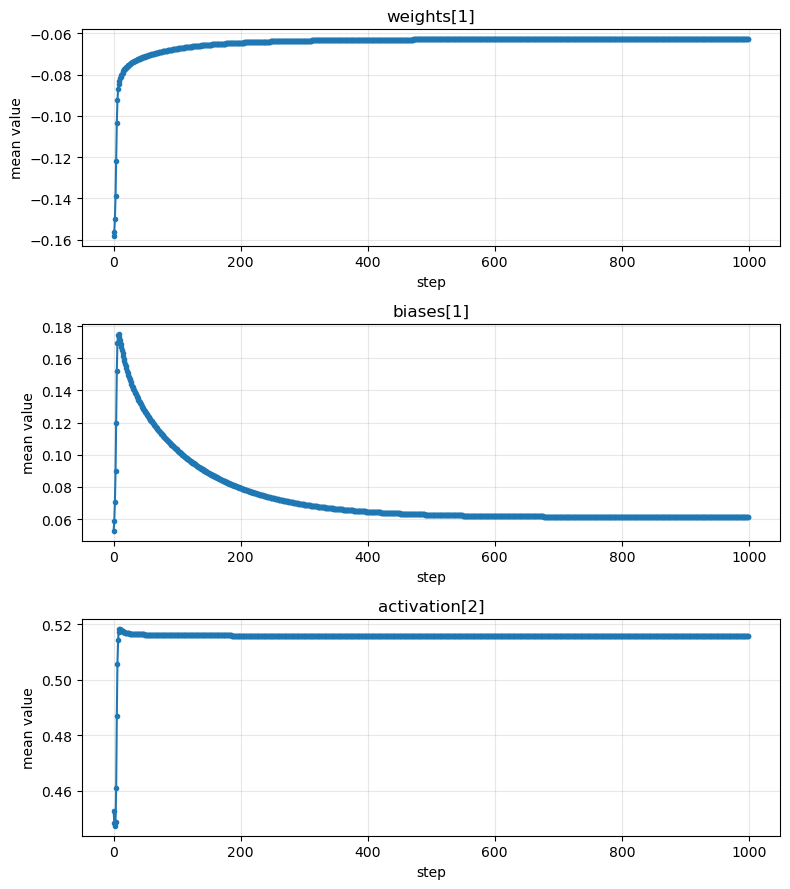

In [ ]:
import numpy as np

rng = np.random.default_rng(1129)


class network(object):
    def __init__(self, shape: list, batch_size: int) -> None:
        """
        创建神经网络

        参数：
            shape:神经网络形状
            batch_size:批量
        """

        self.shape = shape
        self.layer_num = len(shape)
        self.batch_size = batch_size

        self.activation = [
            np.zeros((shape[l], batch_size)) for l in range(self.layer_num)
        ]

        self.weights = [
            rng.normal(0, 1, (shape[l + 1], shape[l]))
            for l in range(self.layer_num - 1)
        ]
        self.grad_w = [
            np.zeros((shape[l + 1], shape[l])) for l in range(self.layer_num - 1)
        ]
        self.biases = [
            rng.normal(0, 1, (shape[l + 1], 1)) for l in range(self.layer_num - 1)
        ]

        self.grad_b = [np.zeros((shape[l + 1], 1)) for l in range(self.layer_num - 1)]

        class cache(object):
            def __init__(self, net) -> None:
                self.z = [
                    np.zeros((shape[l], batch_size)) for l in range(net.layer_num - 1)
                ]
                self.d = [
                    np.zeros((shape[l], batch_size)) for l in range(net.layer_num - 1)
                ]
                pass

        self.cache = cache(self)

    def shape_dict(self, l):
        """
        形状字典

        参数：
            l:显示层数
        """
        return {
            f"activation[{l+1}]": np.shape(self.activation[l + 1]),
            f"weights[{l}]": np.shape(self.weights[l]),
            f"activation[{l}]": np.shape(self.activation[l]),
            f"biases[{l}]": np.shape(self.biases[l]),
            f"z[{l}]": np.shape(self.cache.z[l]),
            f"d[{l}]": np.shape(self.cache.d[l]),
            f"d[{l+1}]": np.shape(self.cache.d[l + 1]),
            f"weights[{l+1}]": np.shape(self.weights[l + 1]),
        }

    def rng_input(self, loc=0, scale=1):
        """
        初始化输入(正态分布随机)

        参数：
            loc:均值
            scale:标准差
        """
        self.activation[0] = rng.normal(loc, scale, np.shape(self.activation[0]))

    def rng_ground_truth(self, loc=0.5, scale=0.1):
        self.gt = rng.normal(loc, scale, np.shape(self.activation[-1]))
        pass

    def shape_test(self, l):
        """
        形状字典

        参数：
            l:显示层数
        """
        return {
            f"d[{-1}]": np.shape(self.cache.d[-1]),
            f"grad_w[{-1}]": np.shape(self.grad_w[-1]),
            f"activation[{-1}]": np.shape(self.activation[-1]),
            f"activation[{-2}]": np.shape(self.activation[-2]),
            f"weights[{-l+1}]": np.shape(self.weights[-l + 1]),
            f"d[{-l}]": np.shape(self.cache.d[-l]),
            f"grad_w[{-l}]": np.shape(self.grad_w[-1]),
            f"activation[{-l}]": np.shape(self.activation[-l]),
        }


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def d_sigmoid(value):
    """
    sigmoid导数

    参数：
        value:sigmoid处理后的值
    """
    return value * (1 - value)


def d_cost(output, ground_truth, batch_size):
    """
    cost的导数

    参数：
        output:输出层数组
        ground_truth:真实值
        batch_size:批量
    """
    return (output - ground_truth) / batch_size


class propagation(object):
    def __init__(self, eta, net: network) -> None:
        self.eta = eta
        self.net = net

    def forward_propagation(self):
        for l in range(self.net.layer_num - 1):
            self.net.cache.z[l] = (
                self.net.weights[l] @ self.net.activation[l] + self.net.biases[l]
            )
            self.net.activation[l + 1] = sigmoid(self.net.cache.z[l])
            self.net.cache.d[l] = d_sigmoid(self.net.activation[l + 1])

    def back_propagation(self):
        d_c = d_cost(self.net.activation[-1], self.net.gt, self.net.batch_size)
        dw = self.net.cache.d[-1] * d_c
        self.net.grad_w[-1] = dw @ self.net.activation[-2].T
        self.net.grad_b[-1] = dw.sum(axis=1, keepdims=True)
        for l in range(2, self.net.layer_num):
            dw = (self.net.weights[-l + 1].T @ dw) * self.net.cache.d[-l]
            self.net.grad_w[-l] = dw @ self.net.activation[-l - 1].T
            self.net.grad_b[-l] = dw.sum(axis=1, keepdims=True)

    def gradient_decent(self):
        for l in range(self.net.layer_num - 1):
            self.net.weights[l] += -self.eta * self.net.grad_w[l]
            self.net.biases[l] += -self.eta * self.net.grad_b[l]
        pass

#可视化部分
import matplotlib.pyplot as plt


class Visualizer:
    """
    通用神经网络可视化器
    用法：
        viz = Visualizer(net)
        viz.plot("weights[0]")                 # 查看单个参数
        viz.plot_many(["activation[0]", "activation[1]", "activation[2]",
                       "grad_w[0]", "cache.z[0]"], cols=2)
    """

    def __init__(self, net):
        self.net = net

    def get(self, name):
        """
        通过字符串获取网络中的任意数据。
        支持写法：
            "activation[0]"   -> net.activation[0]
            "weights[-1]"     -> net.weights[-1]
            "cache.z[0]"      -> net.cache.z[0]
            "grad_b[0]"       -> net.grad_b[0]
            "gt"              -> net.gt
        你也可以直接写 "net.weights[0]"
        """
        # 方便起见，这里用 eval，本地使用足够安全。
        # 如果介意安全性，可以替换成正则解析属性路径。
        if not name.startswith("net."):
            expr = f"net.{name}"
        else:
            expr = name
        try:
            data = eval(expr, {"net": self.net})
        except Exception as e:
            raise KeyError(f"无法获取参数 {name}，请检查名称是否正确。原始错误：{e}")
        return data

    def plot(self, name, ax=None, kind="auto"):
        """
        绘制某个参数的当前值。
        kind: "auto", "bar", "line"
        """
        data = self.get(name)
        arr = np.asarray(data)

        if ax is None:
            fig, ax = plt.subplots()
        else:
            fig = ax.figure

        # ---------- 标量 ----------
        if arr.ndim == 0:
            ax.text(0.5, 0.5,
                    f"{name} = {arr:.6g}",
                    ha="center", va="center",
                    transform=ax.transAxes,
                    fontsize=12)
            ax.set_title(name)
            ax.axis("off")

        # ---------- 一维向量 ----------
        elif arr.ndim == 1:
            if kind == "bar" or (kind == "auto" and arr.size <= 30):
                ax.bar(np.arange(arr.size), arr)
                ax.set_xticks(np.arange(arr.size))
                ax.set_xlabel("index")
                ax.set_ylabel("value")
            else:
                ax.plot(arr, marker="o", markersize=3)
                ax.set_xlabel("index")
                ax.set_ylabel("value")
            ax.set_title(name)
            ax.grid(True, alpha=0.3)

        # ---------- 二维矩阵 ----------
        elif arr.ndim == 2:
            im = ax.imshow(arr, cmap="viridis", aspect="auto")
            fig.colorbar(im, ax=ax)
            ax.set_title(name)
            ax.set_xlabel("batch / cols")
            ax.set_ylabel("units / rows")

        else:
            raise ValueError(f"暂不支持 {arr.ndim} 维数据")

        fig.tight_layout()
        return ax

    def plot_many(self, names, cols=2):
        """
        一次绘制多个参数。
        names: 参数名列表，例如 ["weights[0]", "activation[1]"]
        cols: 每行子图数量
        """
        n = len(names)
        rows = int(np.ceil(n / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
        axes = np.atleast_1d(axes).ravel()

        for ax, name in zip(axes, names):
            self.plot(name, ax=ax)

        # 隐藏多余子图
        for ax in axes[n:]:
            ax.axis("off")

        fig.tight_layout()
        return fig, axes

    def show_shapes(self):
        """
        打印网络中所有层的参数形状，方便查看。
        """
        for l in range(self.net.layer_num - 1):
            print(f"Layer {l} -> {l + 1}:")
            for key in [
                f"activation[{l}]",
                f"weights[{l}]",
                f"biases[{l}]",
                f"cache.z[{l}]",
                f"cache.d[{l}]",
            ]:
                try:
                    print(f"  {key}: {np.shape(self.get(key))}")
                except Exception:
                    pass


class HistoryMonitor:
    """
    训练过程中监控参数的变化趋势。
    由于参数可能是矩阵/向量，这里默认记录其摘要统计量（如均值、范数等）。
    用法：
        monitor = HistoryMonitor(net, ["weights[0]", "grad_w[0]"], summary="mean")
        for step in range(100):
            ...
            monitor.update(step)
    """

    def __init__(self, net, names, summary="mean"):
        """
        net: 你的 network 实例
        names: 要监控的参数名列表
        summary: 摘要类型，可选 "mean", "std", "norm", "max", "min"
        """
        self.net = net
        self.names = names
        self.summary = summary
        self.history = {name: [] for name in names}

        self.fig, self.axes = plt.subplots(len(names), 1,
                                           figsize=(8, 3 * len(names)),
                                           squeeze=False)
        self.lines = {}
        for ax, name in zip(self.axes[:, 0], names):
            line, = ax.plot([], [], marker="o", markersize=3)
            ax.set_title(name)
            ax.set_xlabel("step")
            ax.set_ylabel(f"{summary} value")
            ax.grid(True, alpha=0.3)
            self.lines[name] = (ax, line)

        plt.tight_layout()

    def _summarize(self, data):
        arr = np.asarray(data)
        if arr.size == 1:
            return float(arr)
        if self.summary == "mean":
            return float(np.mean(arr))
        elif self.summary == "std":
            return float(np.std(arr))
        elif self.summary == "norm":
            return float(np.linalg.norm(arr))
        elif self.summary == "max":
            return float(np.max(arr))
        elif self.summary == "min":
            return float(np.min(arr))
        else:
            raise ValueError(f"未知 summary 类型: {self.summary}")

    def update(self, step):
        for name in self.names:
            data = eval(f"net.{name}", {"net": self.net})
            val = self._summarize(data)
            self.history[name].append(val)

            ax, line = self.lines[name]
            line.set_data(range(len(self.history[name])), self.history[name])
            ax.relim()
            ax.autoscale_view()

        # 移除 plt.pause(0.01)，不再动态刷新

    def show(self):
        """训练结束后调用此方法显示图形"""
        plt.show()


batch_size = 3
shape = [784, 128, 64, 10]
eta = 0.05
times=100000

net = network(shape, batch_size)
net.rng_input()
net.rng_ground_truth()
prop = propagation(eta, net)
viz = Visualizer(net)
monitor = HistoryMonitor(net, ["weights[1]", "biases[1]","activation[2]"] ,summary="mean")


for step in range(times):
    prop.forward_propagation()
    prop.back_propagation()
    prop.gradient_decent()
    if step % 100 == 0:
        monitor.update(step)
plt.show()